<a href="https://colab.research.google.com/github/WuDianQiBian/ml-course/blob/master/notebooks/ch02_python_basics/sec09_matplotlib.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<p align="center">
  <img src="https://raw.githubusercontent.com/WuDianQiBian/ml-course/master/assets/banner.jpg" alt="五点七边 Logo" width="900"/>
</p>

# Matplotlib 数据可视化

**本节目标：**

- 了解常见绘图方式
- 熟悉 `matplotlib` 的典型写法
- 需要用到时查阅（不必记住 API）


## 环境准备

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 在 Notebook 中内联显示图表
%matplotlib inline

plt.rcParams['figure.figsize'] = (8, 4)  # 默认图表大小
plt.rcParams['figure.dpi'] = 100         # 默认分辨率

## 1\. 折线图（Line Plot）

### 1.1 基本折线图

`plt.plot()` 是最基本的绘图函数，传入 x 和 y 即可。

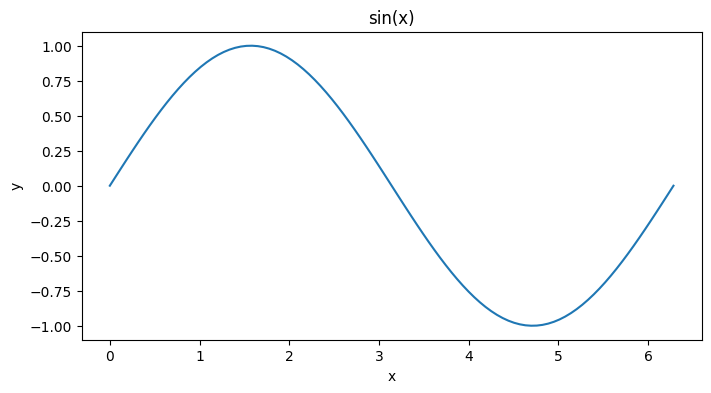

In [2]:
x = np.linspace(0, 2 * np.pi, 100)  # 在 [0, 2π] 上生成 100 个点
y = np.sin(x)                       # 计算 sin 值

plt.plot(x, y)       # 画折线
plt.title('sin(x)')  # 标题
plt.xlabel('x')      # x 轴标签
plt.ylabel('y')      # y 轴标签
plt.show()

### 1.2 多曲线、图例与网格

同一张图上画多条曲线，并添加图例和背景网格：

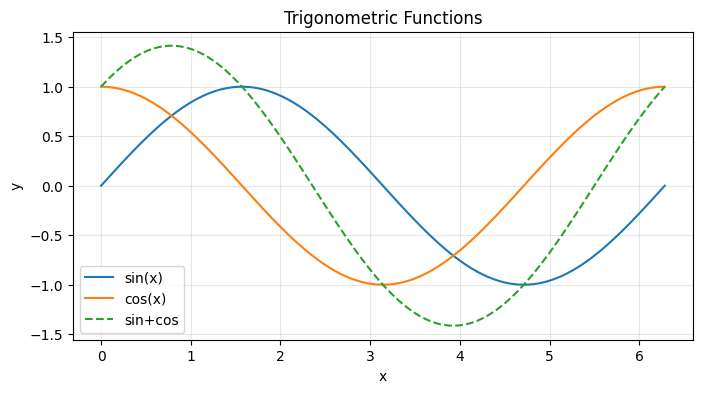

In [3]:
plt.plot(x, np.sin(x), label='sin(x)')     # 默认样式
plt.plot(x, np.cos(x), label='cos(x)')     # 自动换色
plt.plot(x, np.sin(x) + np.cos(x),         # 第三条曲线
         linestyle='--', label='sin+cos')  # 虚线

plt.title('Trigonometric Functions')
plt.xlabel('x')           # x 轴标签
plt.ylabel('y')           # y 轴标签
plt.legend()              # 显示图例
plt.grid(True, alpha=0.3) # 半透明网格
plt.show()

### 1.3 线型、颜色与标记

通过参数自定义线条外观：颜色 (`color`)、线型 (`linestyle`)、标记 (`marker`)。也支持简写格式，如 `'ro--'` = 红色 + 圆点 + 虚线。

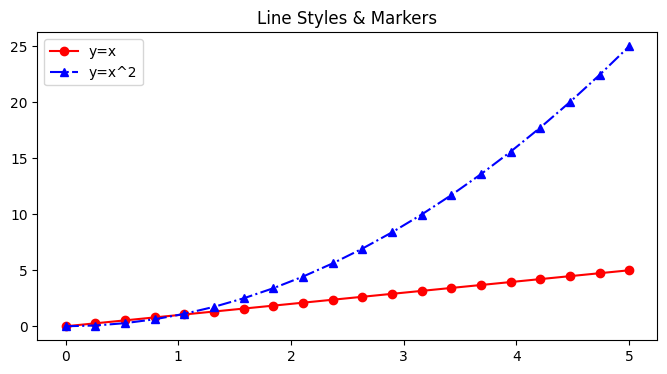

In [4]:
x = np.linspace(0, 5, 20)

# ---- 完整写法 ----
plt.plot(x, x,       # y = x
         color='red',      linestyle='-',   # 红色实线
         marker='o',       label='y=x')     # 圆点标记

# ---- 简写格式 ----
plt.plot(x, x**2, 'b-.^', label='y=x^2')   # 蓝色-点划线-三角

plt.legend()
plt.title('Line Styles & Markers')
plt.show()

## 2\. 散点图（Scatter Plot）

### 2.1 基本散点图

`plt.scatter()` 用于绘制散点图，每个点的位置由 x, y 决定。

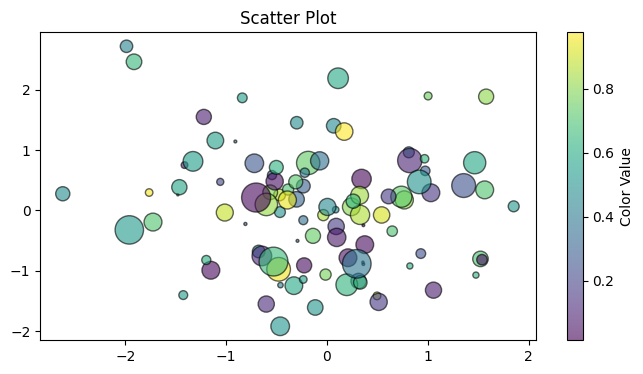

In [5]:
np.random.seed(42)
x = np.random.randn(100)                # 100 个随机 x
y = np.random.randn(100)                # 100 个随机 y
colors = np.random.rand(100)            # 颜色值 (0~1)
sizes = np.abs(np.random.randn(100)) * 200  # 点大小

plt.scatter(
    x, y,              # 坐标
    c=colors,          # 用数值映射颜色
    s=sizes,           # 用数值映射点大小
    alpha=0.6,         # 透明度
    cmap='viridis',    # 颜色映射表
    edgecolors='black' # 边框颜色
)
plt.colorbar(label='Color Value')  # 颜色条
plt.title('Scatter Plot')
plt.show()

### 2.2 分类散点图

散点图常用于展示分类数据：

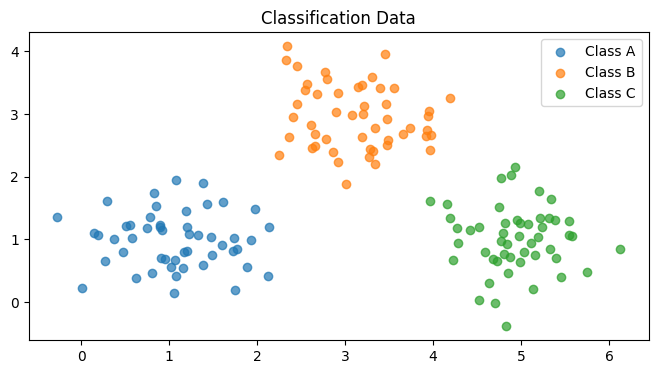

In [6]:
np.random.seed(0)

# 模拟三类数据，每类 50 个点
for cx, cy, label in [(1, 1, 'A'), (3, 3, 'B'), (5, 1, 'C')]:
    x = np.random.randn(50) * 0.5 + cx  # 以 (cx, cy) 为中心
    y = np.random.randn(50) * 0.5 + cy  # 标准差 0.5
    plt.scatter(x, y, label=f'Class {label}', alpha=0.7)

plt.legend()
plt.title('Classification Data')
plt.show()

## 3\. 柱状图（Bar Chart）

### 3.1 基本柱状图

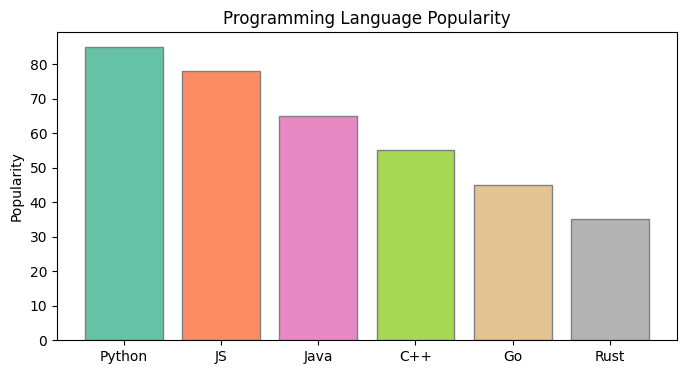

In [7]:
languages = ['Python', 'JS', 'Java', 'C++', 'Go', 'Rust']
popularity = [85, 78, 65, 55, 45, 35]
colors = plt.cm.Set2(np.linspace(0, 1, len(languages)))

plt.bar(languages, popularity,  # 垂直柱状图
        color=colors,           # 每根柱子不同颜色
        edgecolor='gray')       # 边框颜色
plt.ylabel('Popularity')
plt.title('Programming Language Popularity')
plt.show()

### 3.2 分组柱状图

分组柱状图通过偏移 x 坐标实现：

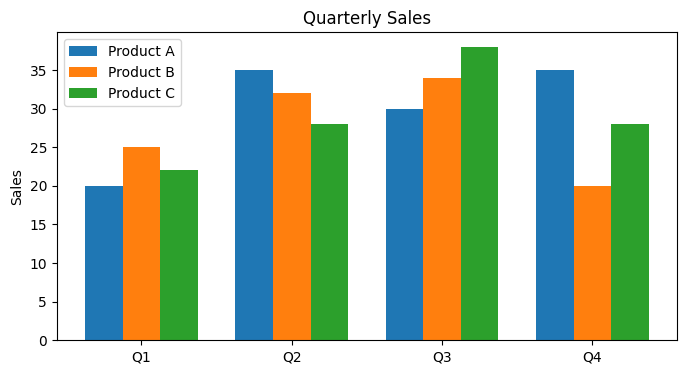

In [8]:
categories = ['Q1', 'Q2', 'Q3', 'Q4']
product_a = [20, 35, 30, 35]
product_b = [25, 32, 34, 20]
product_c = [22, 28, 38, 28]

x = np.arange(len(categories))  # 类别位置 [0,1,2,3]
width = 0.25                    # 每组柱子的宽度

plt.bar(x - width, product_a, width, label='Product A')  # 左侧柱
plt.bar(x,         product_b, width, label='Product B')  # 中间柱
plt.bar(x + width, product_c, width, label='Product C')  # 右侧柱

plt.xticks(x, categories)  # x 轴刻度标签
plt.ylabel('Sales')
plt.title('Quarterly Sales')
plt.legend()
plt.show()

### 3.3 堆叠柱状图

堆叠柱状图用 `bottom` 参数：

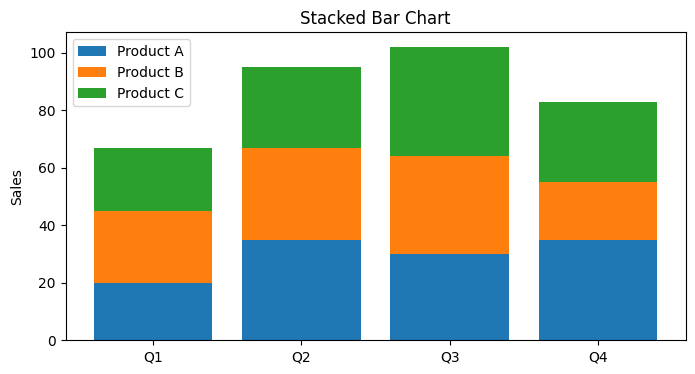

In [9]:
a = np.array(product_a)
b = np.array(product_b)
c = np.array(product_c)

plt.bar(categories, a, label='Product A')                # 底层
plt.bar(categories, b, bottom=a, label='Product B')      # 叠在 A 上方
plt.bar(categories, c, bottom=a + b, label='Product C')  # 叠在 A+B 上方

plt.ylabel('Sales')
plt.title('Stacked Bar Chart')
plt.legend()
plt.show()

## 4\. 直方图（Histogram）

### 4.1 基本直方图

直方图用于展示数据分布，`bins` 控制分箱数量。

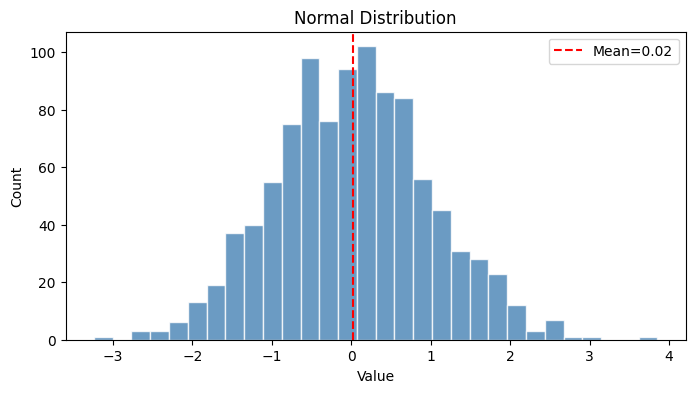

In [10]:
np.random.seed(42)
data = np.random.randn(1000)  # 1000 个标准正态样本

plt.hist(data,
         bins=30,             # 分 30 个箱
         color='steelblue',   # 填充颜色
         edgecolor='white',   # 边框颜色
         alpha=0.8)           # 透明度

plt.axvline(data.mean(), color='red', linestyle='--',  # 均值竖线
            label=f'Mean={data.mean():.2f}')

plt.title('Normal Distribution')
plt.xlabel('Value')
plt.ylabel('Count')
plt.legend()
plt.show()

### 4.2 多组数据叠加

多组数据叠加对比：

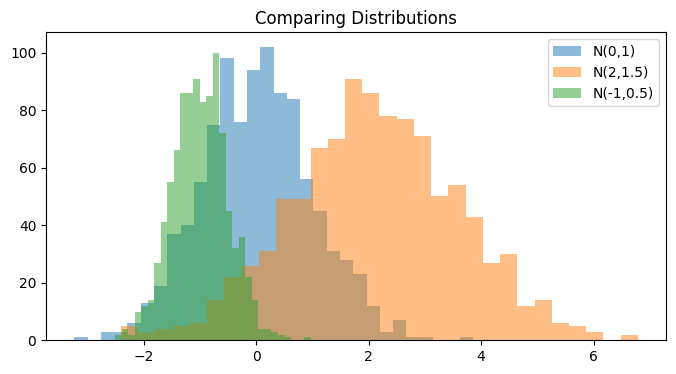

In [11]:
np.random.seed(42)
d1 = np.random.normal(0, 1, 1000)    # 均值=0, 标准差=1
d2 = np.random.normal(2, 1.5, 1000)  # 均值=2, 标准差=1.5
d3 = np.random.normal(-1, 0.5, 1000) # 均值=-1, 标准差=0.5

plt.hist(d1, bins=30, alpha=0.5, label='N(0,1)')    # 半透明叠加
plt.hist(d2, bins=30, alpha=0.5, label='N(2,1.5)')  # 半透明叠加
plt.hist(d3, bins=30, alpha=0.5, label='N(-1,0.5)') # 半透明叠加

plt.legend()
plt.title('Comparing Distributions')
plt.show()

## 5\. 子图（Subplots）

`plt.subplots(rows, cols)` 创建多个子图，返回 `fig` 和 `axes` 对象。不同类型的图表可以组合展示。

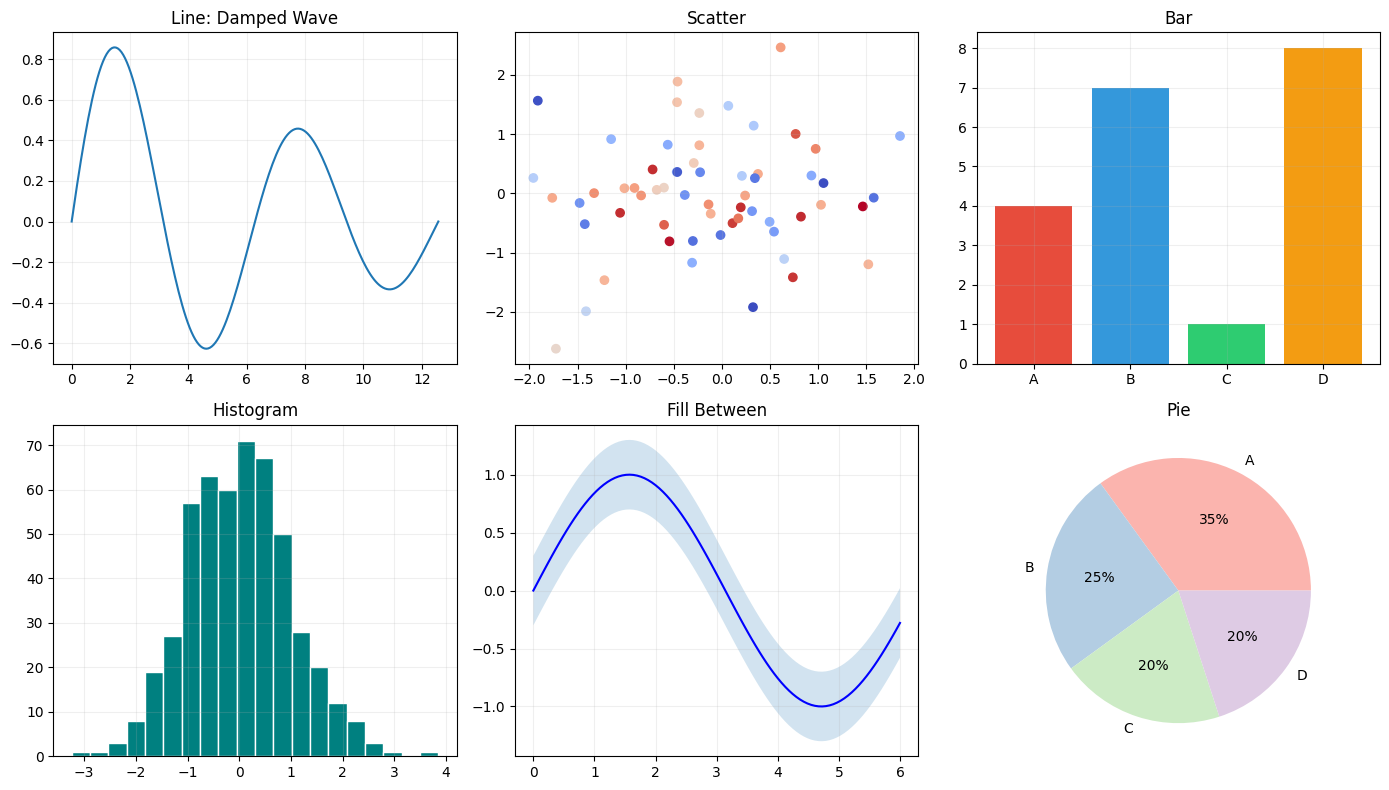

In [12]:
np.random.seed(42)

# 创建 2 行 3 列的子图
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# (0,0) 折线图
t = np.linspace(0, 4*np.pi, 200)
axes[0, 0].plot(t, np.sin(t) * np.exp(-0.1*t))  # 衰减振荡
axes[0, 0].set_title('Line: Damped Wave')

# (0,1) 散点图
axes[0, 1].scatter(
    np.random.randn(60), np.random.randn(60),
    c=np.random.rand(60),  # 颜色映射
    cmap='coolwarm')       # 冷暖色
axes[0, 1].set_title('Scatter')

# (0,2) 柱状图
axes[0, 2].bar(['A','B','C','D'], [4, 7, 1, 8],
               color=['#e74c3c','#3498db','#2ecc71','#f39c12'])
axes[0, 2].set_title('Bar')

# (1,0) 直方图
axes[1, 0].hist(np.random.randn(500),
               bins=20,           # 20 个箱
               color='teal',      # 填充色
               edgecolor='white') # 白色边框
axes[1, 0].set_title('Histogram')

# (1,1) 填充区域
xx = np.linspace(0, 6, 100)
yy = np.sin(xx)
axes[1, 1].plot(xx, yy, 'b-')
axes[1, 1].fill_between(xx, yy - 0.3, yy + 0.3, alpha=0.2)
axes[1, 1].set_title('Fill Between')

# (1,2) 饼图
axes[1, 2].pie([35, 25, 20, 20],
               labels=['A','B','C','D'],
               autopct='%1.0f%%',              # 百分比格式
               colors=plt.cm.Pastel1.colors[:4])
axes[1, 2].set_title('Pie')

# 后处理，绘制
for ax in axes.flat:
    ax.grid(True, alpha=0.2)  # 添加淡网格

fig.tight_layout()
plt.show()

## 6\. 热力图（Heatmap）

`plt.imshow()` 可以将二维数组可视化为热力图，常用于展示相关矩阵。

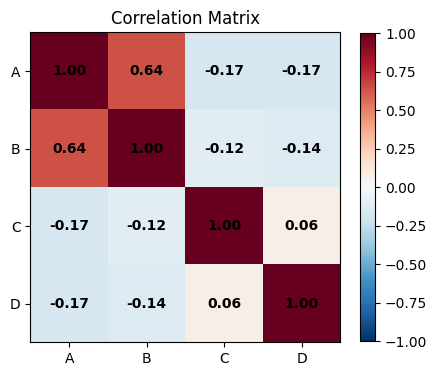

In [13]:
np.random.seed(42)

# 生成 4 组有相关性的数据
a = np.random.randn(100)                   # 独立变量
b = a * 0.5 + np.random.randn(100) * 0.5   # 与 a 正相关
c = -a * 0.3 + np.random.randn(100) * 0.7  # 与 a 负相关
d = np.random.randn(100)                   # 独立变量

matrix = np.column_stack([a, b, c, d])     # 合并为矩阵
corr = np.corrcoef(matrix.T)               # 计算相关系数矩阵
names = ['A', 'B', 'C', 'D']

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(corr,
               cmap='RdBu_r',              # 红蓝配色
               vmin=-1, vmax=1)            # 值域固定 [-1, 1]

for i in range(4):  # 在每个格子中标注数值
    for j in range(4):
        ax.text(j, i, f'{corr[i,j]:.2f}',
                ha='center', va='center', fontweight='bold')

ax.set_xticks(range(4))
ax.set_yticks(range(4))
ax.set_xticklabels(names)
ax.set_yticklabels(names)
plt.colorbar(im, shrink=0.8)
plt.title('Correlation Matrix')
plt.show()

## 7\. 等高线图（Contour Plot）

等高线图展示三维曲面在二维平面上的投影。

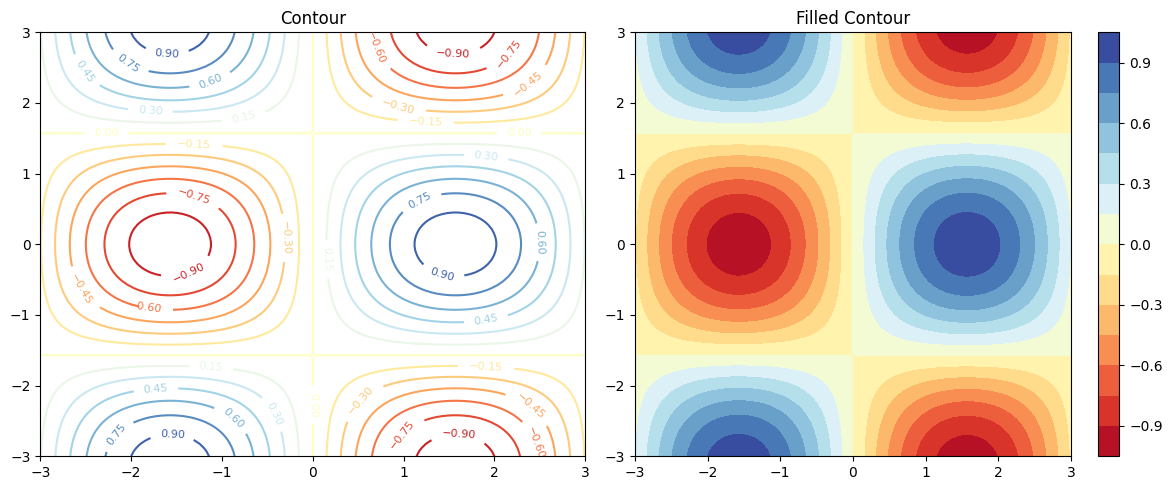

In [14]:
x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x, y)   # 生成网格
Z = np.sin(X) * np.cos(Y)  # 计算高度

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 等高线
cs = ax1.contour(X, Y, Z,
                 levels=15,      # 15 条等高线
                 cmap='RdYlBu')  # 颜色映射
ax1.clabel(cs, inline=True, fontsize=8)  # 标注数值
ax1.set_title('Contour')

# 填充等高线
cf = ax2.contourf(X, Y, Z,
                  levels=15,      # 15 层
                  cmap='RdYlBu')  # 颜色映射
plt.colorbar(cf, ax=ax2)
ax2.set_title('Filled Contour')

# 后处理、绘制
fig.tight_layout()
plt.show()

## 8\. 三维图形（3D Plot）

### 8.1 三维曲面

使用 `mpl_toolkits.mplot3d` 创建三维图形。

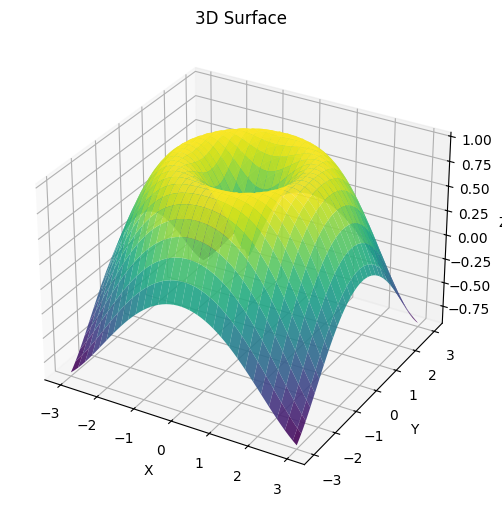

In [15]:
from mpl_toolkits.mplot3d import Axes3D

x = np.linspace(-3, 3, 60)
y = np.linspace(-3, 3, 60)
X, Y = np.meshgrid(x, y)
Z = np.sin(np.sqrt(X**2 + Y**2))  # 以原点为中心的同心波纹

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')  # 创建 3D 子图
ax.plot_surface(X, Y, Z,
                cmap='viridis',   # 颜色映射
                alpha=0.9)        # 透明度
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('3D Surface')
plt.show()

### 8.2 三维散点

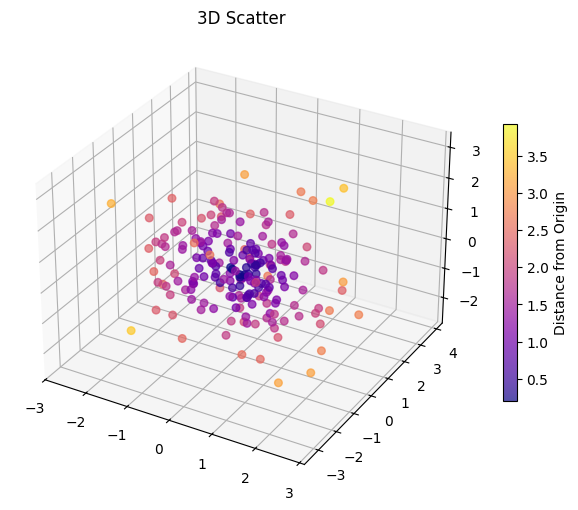

In [16]:
np.random.seed(42)
n = 200
x = np.random.randn(n)
y = np.random.randn(n)
z = np.random.randn(n)
colors = np.sqrt(x**2 + y**2 + z**2)  # 到原点的距离

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(x, y, z,
                c=colors,       # 用距离映射颜色
                cmap='plasma',  # 颜色映射
                s=30,           # 点大小
                alpha=0.7)      # 透明度
plt.colorbar(sc, shrink=0.6, label='Distance from Origin')
ax.set_title('3D Scatter')
plt.show()

## 9\. 图像显示（imshow）

`plt.imshow()` 也常用于直接显示图像数据（NumPy 数组）。

In [17]:
from PIL import Image

# 下载图片
!wget -q --directory-prefix=downloads https://raw.githubusercontent.com/WuDianQiBian/ml-course/master/notebooks/ch02_python_basics/assets/Clark.jpg

img = np.asarray(Image.open('downloads/Clark.jpg'))  # 读取为 NumPy 数组
print(f'shape: {img.shape}')  # (H, W, C)
print(f'dtype: {img.dtype}')  # uint8

shape: (600, 800, 3)
dtype: uint8


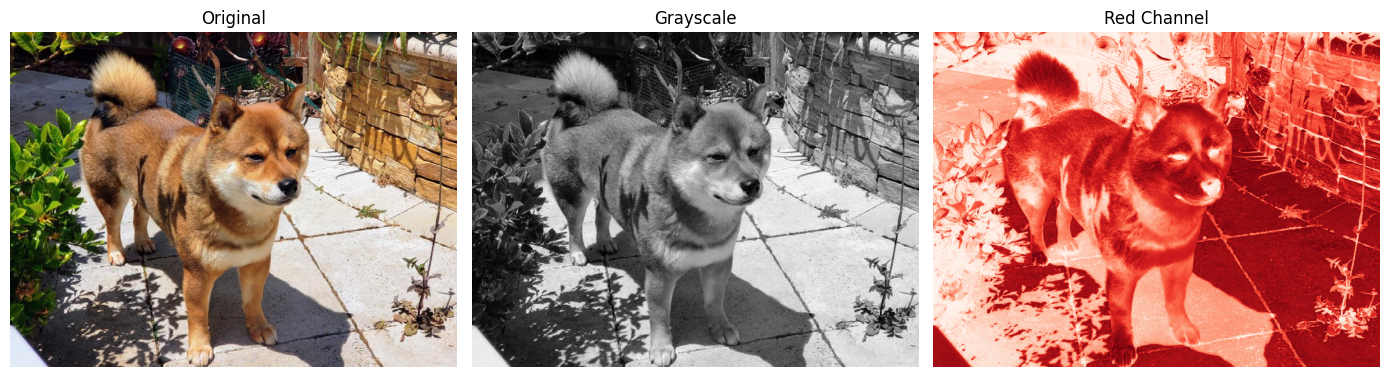

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# 原图 (RGB)
axes[0].imshow(img)
axes[0].set_title('Original')
axes[0].axis('off')  # 隐藏坐标轴

# 灰度图
gray = img.mean(axis=2)            # 三通道取平均
axes[1].imshow(gray, cmap='gray')  # 灰度色映射
axes[1].set_title('Grayscale')
axes[1].axis('off')

# 单通道 (Red)
axes[2].imshow(img[:, :, 0], cmap='Reds')  # 只取 R 通道
axes[2].set_title('Red Channel')
axes[2].axis('off')

fig.tight_layout()
plt.show()

## 10\. 保存图表

`fig.savefig()` 支持多种格式：PNG、PDF、SVG 等。注意要在 `plt.show()` 之前调用。

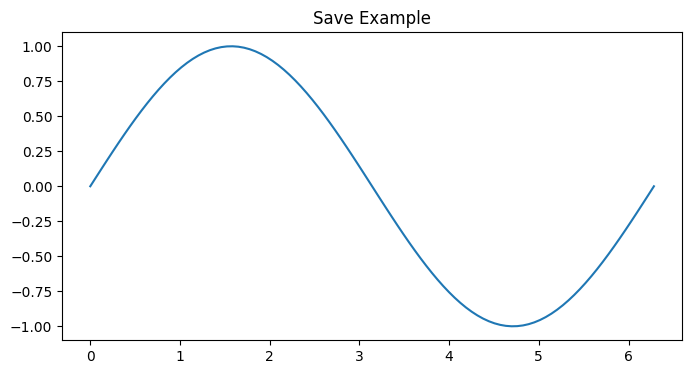

In [19]:
x = np.linspace(0, 2*np.pi, 100)
fig, ax = plt.subplots()
ax.plot(x, np.sin(x))
ax.set_title('Save Example')

fig.savefig('my_plot.png', dpi=200, bbox_inches='tight')  # PNG（高分辨率）
fig.savefig('my_plot.pdf', bbox_inches='tight')           # PDF（矢量图，适合论文）

## 11\. 其他可视化类型

### 11.1 饼图（Pie Chart）

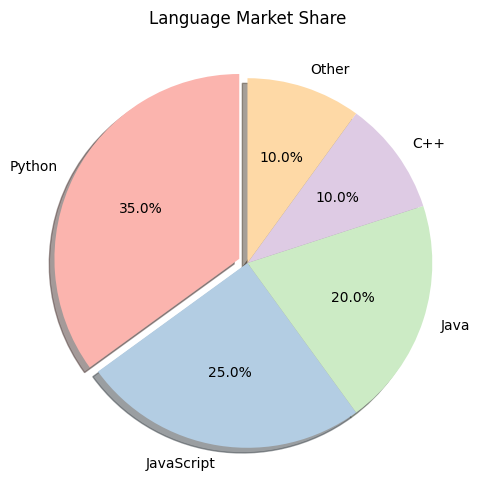

In [20]:
labels = ['Python', 'JavaScript', 'Java', 'C++', 'Other']
sizes = [35, 25, 20, 10, 10]
explode = (0.05, 0, 0, 0, 0)  # 突出显示第一块

plt.figure(figsize=(6, 6))
plt.pie(
    sizes,
    explode=explode,                  # 偏移量
    labels=labels,                    # 标签
    autopct='%1.1f%%',                # 显示百分比
    shadow=True,                      # 阴影
    startangle=90,                    # 起始角度
    colors=plt.cm.Pastel1.colors[:5]  # 柔和配色
)
plt.title('Language Market Share')
plt.show()

### 11.2 填充区域与误差线（Fill & Error Bar）

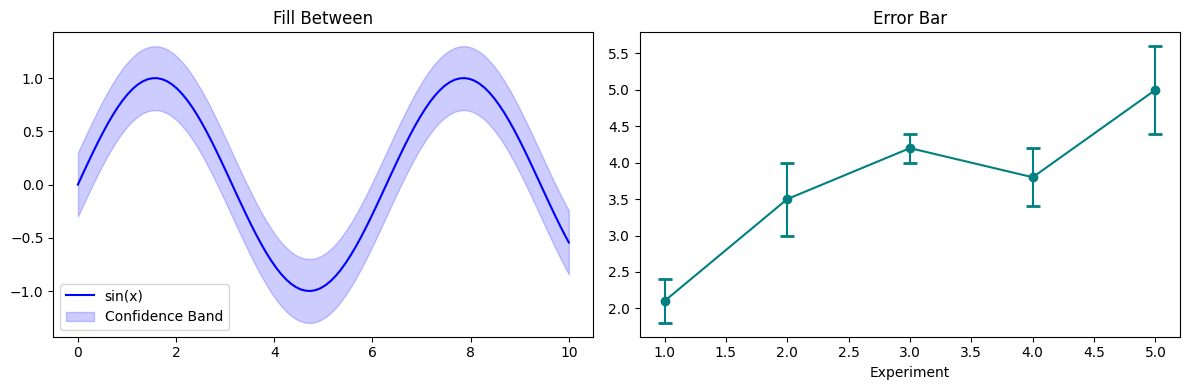

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# 填充区域 —— 常用于展示置信区间
x = np.linspace(0, 10, 100)
y = np.sin(x)
ax1.plot(x, y, 'b-', label='sin(x)')
ax1.fill_between(x, y - 0.3, y + 0.3,  # 上下界
                 alpha=0.2, color='blue',
                 label='Confidence Band')
ax1.legend()
ax1.set_title('Fill Between')

# 误差线
xb = np.arange(1, 6)
yb = [2.1, 3.5, 4.2, 3.8, 5.0]
errors = [0.3, 0.5, 0.2, 0.4, 0.6]
ax2.errorbar(xb, yb,
             yerr=errors,    # 误差范围
             fmt='o-',       # 圆点+折线
             capsize=5,      # 误差线端帽宽度
             capthick=2,     # 端帽线宽
             color='teal')   # 颜色
ax2.set_title('Error Bar')
ax2.set_xlabel('Experiment')

fig.tight_layout()
plt.show()

### 11.3 箱线图与小提琴图（Box & Violin Plot）

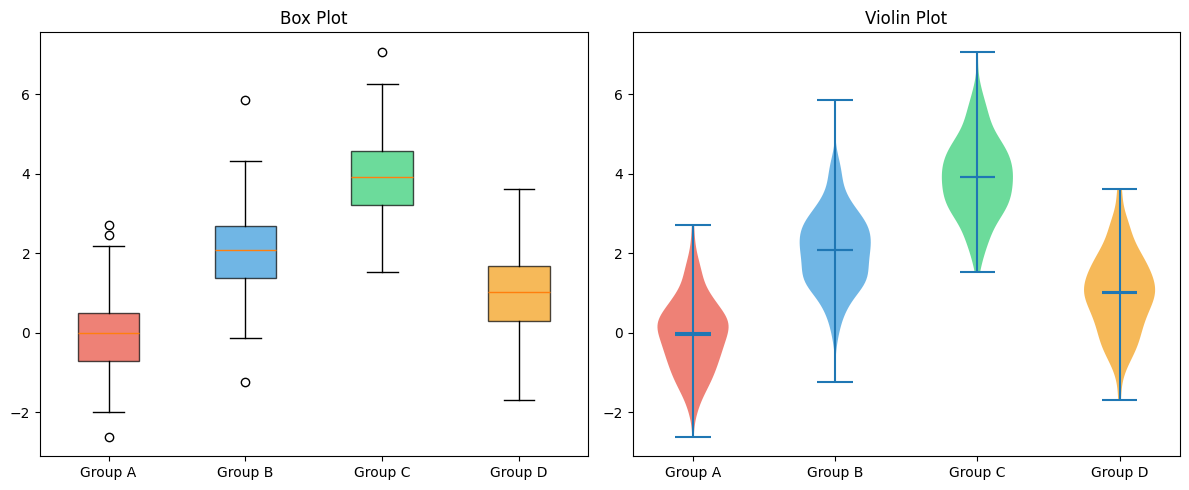

In [22]:
np.random.seed(42)
data = [np.random.normal(loc, 1, 200) for loc in [0, 2, 4, 1]]
labels = ['Group A', 'Group B', 'Group C', 'Group D']
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 箱线图
bp = ax1.boxplot(data, tick_labels=labels, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)  # 填充色
    patch.set_alpha(0.7)        # 透明度
ax1.set_title('Box Plot')

# 小提琴图
vp = ax2.violinplot(data,
                    showmeans=True,    # 显示均值
                    showmedians=True)  # 显示中位数
for i, body in enumerate(vp['bodies']):
    body.set_facecolor(colors[i])
    body.set_alpha(0.7)
ax2.set_xticks([1, 2, 3, 4])
ax2.set_xticklabels(labels)
ax2.set_title('Violin Plot')

fig.tight_layout()
plt.show()

### 11.4 文本注释（Text & Annotation）

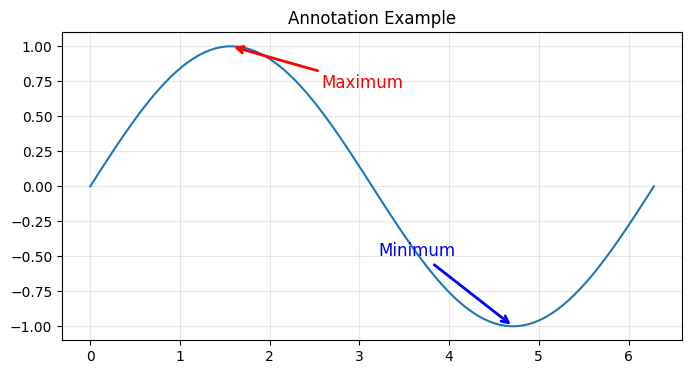

In [23]:
x = np.linspace(0, 2 * np.pi, 100)
y = np.sin(x)
plt.plot(x, y)

# 标注最大值
plt.annotate(
    'Maximum',
    xy=(np.pi/2, 1),            # 箭头指向位置
    xytext=(np.pi/2 + 1, 0.7),  # 文本位置
    fontsize=12, color='red',
    arrowprops=dict(arrowstyle='->', color='red', lw=2))

# 标注最小值
plt.annotate(
    'Minimum',
    xy=(3*np.pi/2, -1),              # 箭头指向位置
    xytext=(3*np.pi/2 - 1.5, -0.5),  # 文本位置
    fontsize=12, color='blue',
    arrowprops=dict(arrowstyle='->', color='blue', lw=2))

plt.title('Annotation Example')
plt.grid(True, alpha=0.3)
plt.show()

### 11.5 极坐标图 — 雷达图（Radar Chart）

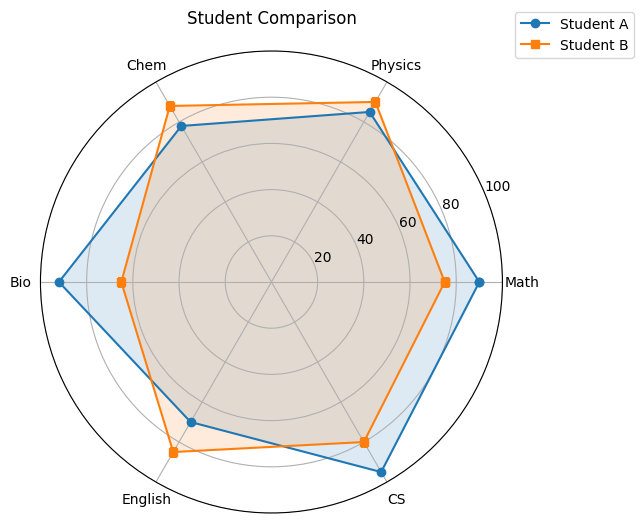

In [24]:
categories = ['Math', 'Physics', 'Chem', 'Bio', 'English', 'CS']
student_a = [90, 85, 78, 92, 70, 95]
student_b = [75, 90, 88, 65, 85, 80]

# 闭合多边形（首尾相连）
angles = np.linspace(0, 2*np.pi, len(categories),
                     endpoint=False).tolist()
student_a += student_a[:1]  # 闭合 A
student_b += student_b[:1]  # 闭合 B
angles += angles[:1]        # 闭合角度

fig, ax = plt.subplots(figsize=(6, 6),
                       subplot_kw={'projection': 'polar'})

ax.plot(angles, student_a, 'o-', label='Student A')
ax.fill(angles, student_a, alpha=0.15)
ax.plot(angles, student_b, 's-', label='Student B')
ax.fill(angles, student_b, alpha=0.15)

ax.set_thetagrids(np.degrees(angles[:-1]), categories)
ax.set_ylim(0, 100)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax.set_title('Student Comparison', pad=20)
plt.show()

### 11.6 双 Y 轴图（Twin Axes）

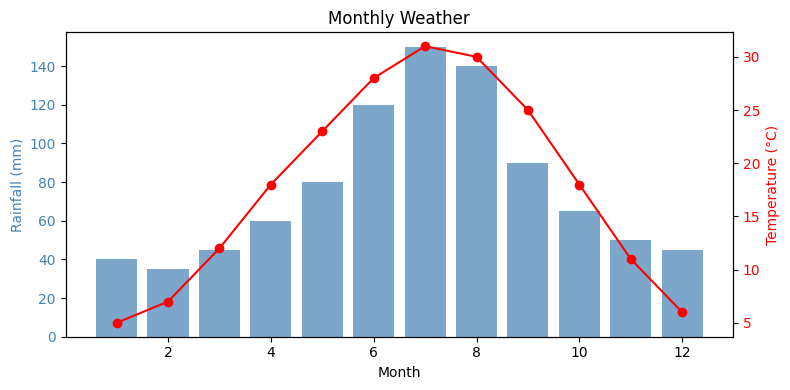

In [25]:
months = np.arange(1, 13)
temperature = [5, 7, 12, 18, 23, 28, 31, 30, 25, 18, 11, 6]
rainfall = [40, 35, 45, 60, 80, 120, 150, 140, 90, 65, 50, 45]

fig, ax1 = plt.subplots(figsize=(8, 4))

# 左 y 轴: 降水量
ax1.bar(months, rainfall,
        color='steelblue', alpha=0.7,
        label='Rainfall (mm)')
ax1.set_xlabel('Month')
ax1.set_ylabel('Rainfall (mm)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

# 右 y 轴: 气温
ax2 = ax1.twinx()  # 共享 x 轴的第二个 y 轴
ax2.plot(months, temperature, 'ro-', label='Temperature')
ax2.set_ylabel('Temperature (°C)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Monthly Weather')
fig.tight_layout()
plt.show()